In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


df= pd.read_csv(r"C:\Users\user\Desktop\scraping\data\scraped_data.csv", encoding="utf-8-sig")

In [5]:
df

,titre,prix,ville,surface,chambres,salle_de_bain,lien
0,Appartement à vendre 154 m² à Marrakech,2 475 000 DH,"Appartements dans Marrakech, Route de Casablanca",154 m²,3 chambres,3 sdbs,https://www.avito.ma/fr/route_de_casablanca/ap...
1,Appartement à vendre 140 m² la marina Casablanca,3 900 000 DH,"Appartements dans Casablanca, Marina",155 m²,2 chambres,3 sdbs,https://www.avito.ma/fr/marina/appartements/Ap...
2,Appartement à vendre 61 m² à Marrakech,1 530 000 DH,"Appartements dans Marrakech, Guéliz",61 m²,1 chambre,1 sdb,https://www.avito.ma/fr/gu%C3%A9liz/appartemen...
3,Appartement à vendre à Temara,960 000 DH,"Appartements dans Temara, Autre secteur",128 m²,3 chambres,1 sdb,https://www.avito.ma/fr/autre_secteur/appartem...
4,Appartement en vente 61m² à Gueliz Piscine Roo...,1 500 000 DH,"Appartements dans Marrakech, Guéliz",61 m²,1 chambre,1 sdb,https://www.avito.ma/fr/gu%C3%A9liz/appartemen...
...,...,...,...,...,...,...,...
826,Nour Confort Targa,1 024 600 DH,Immobilier neuf dans Casablanca,NaN,NaN,NaN,https://immoneuf.avito.ma/fr/unite/UIH?utm_sou...
827,Joli Appartement 1er Etage Mhamid 7,410 000 DH,"Appartements dans Marrakech, M'Hamid",57 m²,2 chambres,1 sdb,https://www.avito.ma/fr/m_hamid/appartements/J...
828,"🌊 appartement vue mer en face, sans vis-à-vis",1 600 000 DH,"Appartements dans Agadir, Anza",80 m²,2 chambres,2 sdbs,https://www.avito.ma/fr/anza/appartements/___a...
829,Rez-de-jardin à vendre 128 m² 20 m² jardin,2 100 000 DH,"Appartements dans Rabat, Souissi",148 m²,3 chambres,2 sdbs,https://www.avito.ma/fr/souissi/appartements/R...


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   titre          831 non-null    object
 1   prix           831 non-null    object
 2   ville          831 non-null    object
 3   surface        680 non-null    object
 4   chambres       680 non-null    object
 5   salle_de_bain  680 non-null    object
 6   lien           831 non-null    object
dtypes: object(7)
memory usage: 45.6+ KB


# Nettoyage des données (Clean Layer)

In [ ]:
import pandas as pd
import numpy as np


# 1. LOAD DATA


df= pd.read_csv(r"C:\Users\user\Desktop\scraping\data\scraped_data.csv", encoding="utf-8-sig")

# IMPORTANT: avoid SettingWithCopyWarning
df = df.copy()

# 2. CLEAN PRIX

df["prix"] = (
    df["prix"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
    .astype(float)
)


# 3. CLEAN SURFACE

df["surface"] = (
    df["surface"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)


# 4. CLEAN CHAMBRES & SALLE DE BAIN

df["chambres"] = df["chambres"].astype(str).str.extract(r"(\d+)")[0].astype(float)
df["salle_de_bain"] = df["salle_de_bain"].astype(str).str.extract(r"(\d+)")[0].astype(float)


# 5. CLEAN VILLE

df["ville"] = df["ville"].astype(str).str.split(",").str[0]
df["ville"] = df["ville"].astype("category")


# 6. REMOVE OUTLIERS (PRIX)

q_low = df["prix"].quantile(0.01)
q_high = df["prix"].quantile(0.99)

df = df[(df["prix"] >= q_low) & (df["prix"] <= q_high)]


# 7. FEATURE ENGINEERING

df["prix_log"] = np.log1p(df["prix"])

df["prix_par_m2"] = df["prix"] / df["surface"]


# 8. DROP MISSING IMPORTANT DATA

df = df.dropna(subset=["prix", "surface"])


# 9. RESET INDEX

df = df.reset_index(drop=True)


# 10. SAVE CLEAN DATA

df.to_csv(r"C:\Users\user\Desktop\scraping\cleaned_data.csv", index=False, encoding="utf-8-sig")

In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 680 entries, 0 to 829
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   titre          680 non-null    object  
 1   prix           680 non-null    int64   
 2   ville          680 non-null    category
 3   surface        680 non-null    float64 
 4   chambres       0 non-null      float64 
 5   salle_de_bain  0 non-null      float64 
 6   lien           680 non-null    object  
dtypes: category(1), float64(3), int64(1), object(2)
memory usage: 48.3+ KB


,prix,surface,chambres,salle_de_bain
count,6.800000e+02,680.000000,0.0,0.0
mean,3.224106e+06,101.291176,NaN,NaN
std,3.584385e+07,45.258842,NaN,NaN
min,1.800000e+05,35.000000,NaN,NaN
25%,6.400000e+05,70.000000,NaN,NaN
50%,1.000000e+06,90.000000,NaN,NaN
75%,1.600000e+06,123.000000,NaN,NaN
max,6.624512e+08,366.000000,NaN,NaN


In [10]:
df["prix"].skew()

np.float64(18.37787785542508)

In [11]:
import numpy as np

df["prix_log"] = np.log1p(df["prix"])

C:\Users\user\AppData\Local\Temp\ipykernel_2092\2520173849.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prix_log"] = np.log1p(df["prix"])


In [12]:
df["prix_log"].skew()

np.float64(1.8163141219714638)

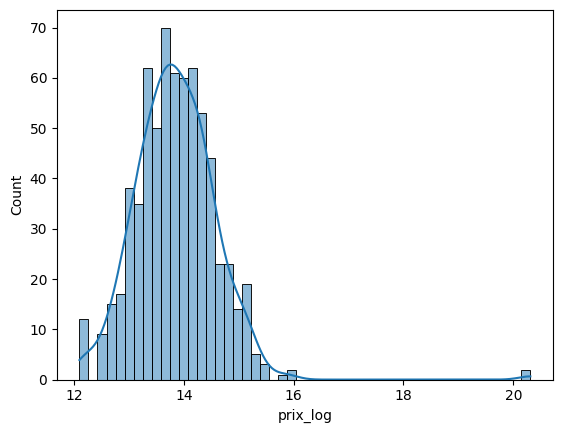

In [13]:
sns.histplot(df["prix_log"],kde= True , bins=50)
plt.show()

In [14]:
Q1 = df["prix"].quantile(0.25)
Q3 = df["prix"].quantile(0.75)
IQR = Q3 - Q1

borne_sup = Q3 + 1.5 * IQR

df["prix"] = df["prix"].clip(upper=borne_sup)

C:\Users\user\AppData\Local\Temp\ipykernel_2092\3952806346.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prix"] = df["prix"].clip(upper=borne_sup)


In [15]:
df.sort_values(by="prix", ascending=False).head(10)

,titre,prix,ville,surface,chambres,salle_de_bain,lien,prix_log
1,Appartement à vendre 140 m² la marina Casablanca,3040000,"Appartements dans Casablanca, Marina",155.0,NaN,NaN,https://www.avito.ma/fr/marina/appartements/Ap...,15.176487
805,"Appartement à vendre 181 m² avec terrasse, Racine",3040000,"Appartements dans Casablanca, Racine",181.0,NaN,NaN,https://www.avito.ma/fr/racine/appartements/Ap...,14.946913
795,Superbe Appart à vendre à Ain Diab Extension,3040000,"Appartements dans Casablanca, Aïn Diab",189.0,NaN,NaN,https://www.avito.ma/fr/a%C3%AFn_diab/appartem...,15.201805
57,CMN-SI-1879 - Appartement à vendre à Ziraoui,3040000,"Appartements dans Casablanca, Bourgogne",260.0,NaN,NaN,https://www.avito.ma/fr/bourgogne/appartements...,15.062543
53,Appartement titré à vendre 28 millions,3040000,"Appartements dans Salé, Sidi Moussa",48.0,NaN,NaN,https://www.avito.ma/fr/sidi_moussa/appartemen...,20.311458
62,Appartement à vendre 165 m² à Casablanca,3040000,"Appartements dans Casablanca, Racine",176.0,NaN,NaN,https://www.avito.ma/fr/racine/appartements/Ap...,15.068274
76,Appartement titré résidence gardée 60 millions..,3040000,"Appartements dans Salé, Toute la ville",67.0,NaN,NaN,https://www.avito.ma/fr/sal%C3%A9/appartements...,20.311458
729,Très bel appartement a Eden island,3040000,"Appartements dans Bouznika, Plage Oued Cherrat",251.0,NaN,NaN,https://www.avito.ma/fr/plage_oued_cherrat/app...,15.110238
648,Appartement spacieux a vendre sur PRESTIGIA,3040000,"Appartements dans Rabat, Hay Riad",248.0,NaN,NaN,https://www.avito.ma/fr/hay_riad/appartements/...,15.520259
142,Appartement à vendre 199 m² à Boulevard Zerktouni,3040000,"Appartements dans Casablanca, Maarif",199.0,NaN,NaN,https://www.avito.ma/fr/maarif/appartements/Ap...,15.150512


# Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime


def feature_engineering(df):

    df = df.copy()

  
    # 1. BASIC CLEAN
   
    df = df.dropna(subset=["prix", "surface", "ville"])
    df = df[df["surface"] > 0]
    df = df[df["prix"] > 0]

   
    # 2. FEATURE CORE
   
    df["prix_par_m2"] = df["prix"] / df["surface"]


    # 3. GEO CLEAN
   
    df["ville"] = df["ville"].astype(str).str.strip().str.lower()

    if "quartier" in df.columns:
        df["quartier"] = df["quartier"].astype(str).str.strip().str.lower()

   
    # 4. MARKET FEATURES
    
    df["nb_annonces_ville"] = df.groupby("ville")["prix"].transform("count")

    if "quartier" in df.columns:
        df["nb_annonces_quartier"] = df.groupby("quartier")["prix"].transform("count")

   
    # 5. SEGMENTATION PRIX
    
    df["segment_prix"] = pd.qcut(
        df["prix"],
        q=3,
        labels=["low", "medium", "high"]
    )

   
    # 6. SEGMENTATION SURFACE
   
    df["segment_surface"] = pd.cut(
        df["surface"],
        bins=[0, 50, 100, 200, 1000],
        labels=["small", "medium", "large", "luxury"]
    )

   
    # 7. AGE BIEN (optional)
  
    if "annee_construction" in df.columns:
        current_year = datetime.now().year
        df["age_bien"] = current_year - df["annee_construction"]
        df["age_bien"] = df["age_bien"].clip(lower=0)

    
    # 8. OUTLIER FILTER (SAFE)

    df = df[df["prix"] < df["prix"].quantile(0.99)]
    df = df[df["surface"] < df["surface"].quantile(0.99)]

    
    # 9. FINAL CLEAN (SAFE)
  
    df = df.reset_index(drop=True)

    return df

In [17]:
print(df.columns)
print(df.head())

Index(['titre', 'prix', 'ville', 'surface', 'chambres', 'salle_de_bain',
       'lien', 'prix_log'],
      dtype='object')
                                               titre     prix  \
0            Appartement à vendre 154 m² à Marrakech  2475000   
1   Appartement à vendre 140 m² la marina Casablanca  3040000   
2             Appartement à vendre 61 m² à Marrakech  1530000   
3                      Appartement à vendre à Temara   960000   
4  Appartement en vente 61m² à Gueliz Piscine Roo...  1500000   

                                              ville  surface  chambres  \
0  Appartements dans Marrakech, Route de Casablanca    154.0       NaN   
1              Appartements dans Casablanca, Marina    155.0       NaN   
2               Appartements dans Marrakech, Guéliz     61.0       NaN   
3           Appartements dans Temara, Autre secteur    128.0       NaN   
4               Appartements dans Marrakech, Guéliz     61.0       NaN   

   salle_de_bain                         

In [18]:
df.to_csv(r"C:\Users\user\Desktop\scraping\cleaned_data.csv", index=False, encoding="utf-8-sig")